In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import nltk
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize 
from collections import Counter
from wordcloud import WordCloud 


In [2]:
import re 
import warnings
warnings.filterwarnings("ignore")


In [3]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /Users/ayush/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/ayush/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df = pd.read_csv("hospital.csv")

In [5]:
df.shape


(996, 4)

In [6]:
df.info

<bound method DataFrame.info of                                               Feedback  Sentiment Label  \
0    Good and clean hospital. There is great team o...                1   
1    Had a really bad experience during discharge. ...                1   
2    I have visited to take my second dose and Proc...                1   
3     That person was slightly clueless and offered...                1   
4    There is great team of doctors and good OT fac...                0   
..                                                 ...              ...   
991  very careful about safety measures every one i...                1   
992  I do not trust in their reports I got same tes...                0   
993  They just want the patients to return to their...                0   
994  I suggest you not to visit this hospital if yo...                0   
995  NU hospital has provided us the excellent serv...                1   

     Ratings  Unnamed: 3  
0          5         NaN  
1          5 

In [7]:
df.head()

,Feedback,Sentiment Label,Ratings,Unnamed: 3
0,Good and clean hospital. There is great team o...,1,5,NaN
1,Had a really bad experience during discharge. ...,1,5,NaN
2,I have visited to take my second dose and Proc...,1,4,NaN
3,That person was slightly clueless and offered...,1,3,NaN
4,There is great team of doctors and good OT fac...,0,1,NaN


In [8]:
#getting a idea of the reviews 

print(df["Feedback"][20])

Thanks to the Emergency doctor abhishek and Thanks to the security guard there


In [9]:
# looking at info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Feedback         996 non-null    object 
 1   Sentiment Label  996 non-null    int64  
 2   Ratings          996 non-null    int64  
 3   Unnamed: 3       0 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 31.3+ KB


In [10]:
#checking missing values 
print(df.isnull().sum())

Feedback             0
Sentiment Label      0
Ratings              0
Unnamed: 3         996
dtype: int64


In [11]:
# check for duplicate values 
duplicates = df.duplicated(subset=['Feedback']).sum()
print("duplicated reviews: ", duplicates)


duplicated reviews:  45


In [12]:
df = df.drop_duplicates(subset=['Feedback'])
print(df.shape)

(951, 4)


In [13]:
#### Review Length Analysis 

df["Feedback_Length"] = df["Feedback"].apply(lambda x: len(str(x).split()))
df["Feedback_Length"].describe()


count    951.000000
mean      20.362776
std       10.386522
min        1.000000
25%       14.000000
50%       19.000000
75%       25.000000
max      149.000000
Name: Feedback_Length, dtype: float64

Text(0, 0.5, 'Frequency')

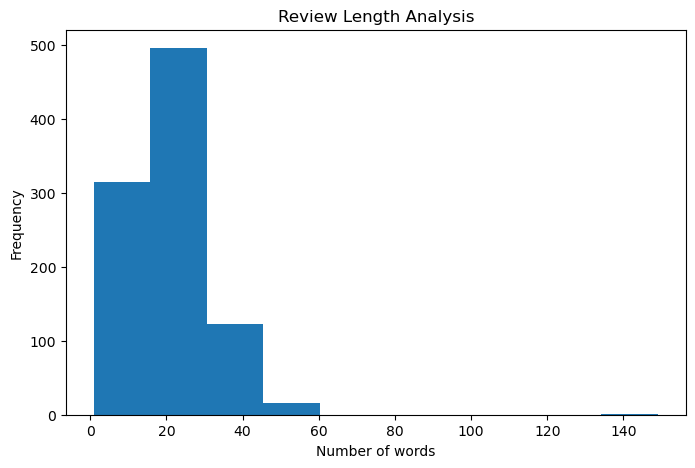

In [14]:
plt.figure(figsize = (8,5))
plt.hist(df["Feedback_Length"], bins = 10)
plt.title("Review Length Analysis")
plt.xlabel("Number of words")
plt.ylabel("Frequency")

We want to see the words with the highest frequency to make sure that they arent stopwords because it will effect the way the model sees words within the reviews. We want to leave the words that will have the most impact or weighting within the reviews


In [15]:
##Basic Word Frequency Analysis 

all_words = " ".join(df["Feedback"]).lower()
tokens = all_words.split()
word_count = Counter(tokens)
print(word_count)

Counter({'the': 869, 'and': 861, 'to': 439, 'is': 381, 'very': 353, 'for': 314, 'hospital': 301, 'i': 278, 'a': 260, 'are': 256, 'good': 252, 'in': 237, 'with': 209, 'of': 204, 'was': 198, 'they': 176, 'staff': 170, 'my': 165, 'all': 131, 'dr': 127, 'doctors': 124, 'we': 122, 'experience': 118, 'service': 114, 'you': 113, 'from': 110, 'this': 108, 'had': 107, 'not': 105, 'at': 103, 'doctor': 102, 'care': 99, 'have': 99, 'treatment': 97, 'patient': 92, 'well': 89, 'by': 76, 'but': 74, 'it': 73, 'an': 70, 'worst': 68, 'that': 67, 'were': 67, 'excellent': 66, 'also': 63, 'really': 63, 'no': 63, 'team': 59, 'be': 59, 'patients': 59, 'their': 59, 'so': 57, 'will': 57, 'as': 57, 'she': 56, 'me': 55, 'time': 55, 'us': 53, 'staffs': 51, 'one': 51, 'has': 51, 'helpful': 50, 'hospital.': 49, 'there': 49, 'great': 49, 'on': 47, 'he': 47, 'best': 47, 'get': 46, 'nursing': 46, 'emergency': 45, 'services': 44, 'nurses': 44, 'thanks': 41, 'our': 41, 'if': 40, 'more': 39, 'health': 38, 'am': 38, 'here

In [16]:
common_words = pd.DataFrame(word_count.most_common(20), columns=["Word","Frequency"])
print(common_words)

        Word  Frequency
0        the        869
1        and        861
2         to        439
3         is        381
4       very        353
5        for        314
6   hospital        301
7          i        278
8          a        260
9        are        256
10      good        252
11        in        237
12      with        209
13        of        204
14       was        198
15      they        176
16     staff        170
17        my        165
18       all        131
19        dr        127


Text(0, 0.5, 'Frequency')

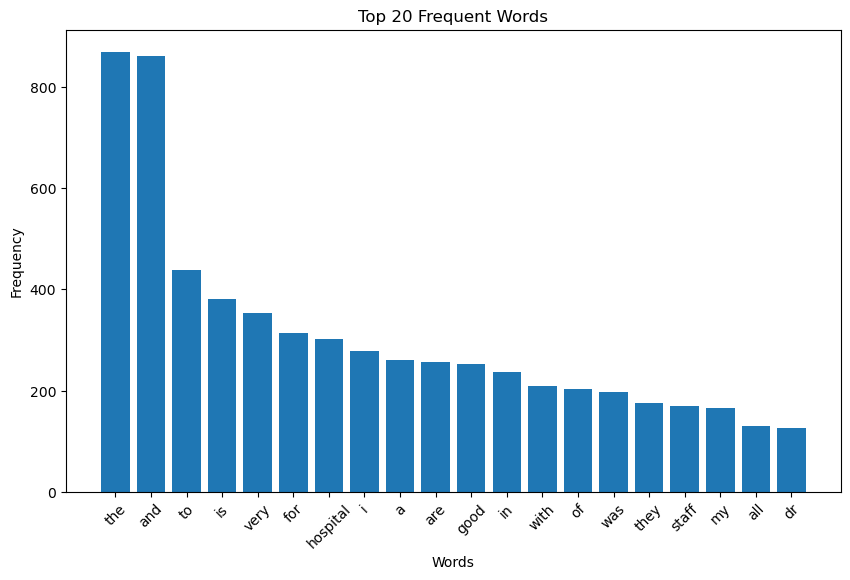

In [17]:
plt.figure(figsize = (10,6))
plt.bar(common_words["Word"],common_words["Frequency"])
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

## TEXT PREPROCESSING 

In [18]:
##converting all reviews to lower case 
df["Feedback"] = df["Feedback"].str.lower()
df["Feedback"].head()

0    good and clean hospital. there is great team o...
1    had a really bad experience during discharge. ...
2    i have visited to take my second dose and proc...
3     that person was slightly clueless and offered...
4    there is great team of doctors and good ot fac...
Name: Feedback, dtype: object

In [20]:
## Remove punctuation marks 
import string
df["Feedback"] = df["Feedback"].str.translate(str.maketrans('','', string.punctuation))

In [21]:
## Remove numbers 
df["Feedback"] = df["Feedback"].apply(lambda x: re.sub(r"\d+","", x))

In [22]:
## Remove extra spaces 
df["Feedback"] = df["Feedback"].str.replace(r"\s+"," ", regex=True).str.strip()

In [23]:
## Tokenise 
## We need to divide the reviews into word tokens 
df["Tokens"] = df["Feedback"].apply(word_tokenize)

In [24]:
df[["Feedback","Tokens"]]

,Feedback,Tokens
0,good and clean hospital there is great team of...,"[good, and, clean, hospital, there, is, great,..."
1,had a really bad experience during discharge t...,"[had, a, really, bad, experience, during, disc..."
2,i have visited to take my second dose and proc...,"[i, have, visited, to, take, my, second, dose,..."
3,that person was slightly clueless and offered ...,"[that, person, was, slightly, clueless, and, o..."
4,there is great team of doctors and good ot fac...,"[there, is, great, team, of, doctors, and, goo..."
...,...,...
991,very careful about safety measures every one i...,"[very, careful, about, safety, measures, every..."
992,i do not trust in their reports i got same tes...,"[i, do, not, trust, in, their, reports, i, got..."
993,they just want the patients to return to their...,"[they, just, want, the, patients, to, return, ..."
994,i suggest you not to visit this hospital if yo...,"[i, suggest, you, not, to, visit, this, hospit..."


In [25]:
## For sentiment analysis it is important to make sure that when u remove stopwords it doesnt affect the sentiment of the review 
negations = {"not","no","never","didnt"}
stop_words= set(stopwords.words("english")) - negations
df["StoppedTokens"] = df["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words])

In [26]:
df[["Tokens","StoppedTokens"]]

,Tokens,StoppedTokens
0,"[good, and, clean, hospital, there, is, great,...","[good, clean, hospital, great, team, doctors, ..."
1,"[had, a, really, bad, experience, during, disc...","[really, bad, experience, discharge, need, sen..."
2,"[i, have, visited, to, take, my, second, dose,...","[visited, take, second, dose, process, really,..."
3,"[that, person, was, slightly, clueless, and, o...","[person, slightly, clueless, offered, one, pac..."
4,"[there, is, great, team, of, doctors, and, goo...","[great, team, doctors, good, ot, facility]"
...,...,...
991,"[very, careful, about, safety, measures, every...","[careful, safety, measures, every, one, friend..."
992,"[i, do, not, trust, in, their, reports, i, got...","[not, trust, reports, got, tests, done, outsid..."
993,"[they, just, want, the, patients, to, return, ...","[want, patients, return, hospital, shell, mone..."
994,"[i, suggest, you, not, to, visit, this, hospit...","[suggest, not, visit, hospital, care, health, ..."


In [33]:
def handle_negations(tokens):
    result = []
    i = 0
    while i < len(tokens):
        if tokens[i] in negations and i < len(tokens) - 1:
            result.append(tokens[i] + "_" + tokens[i+1])
            i += 2
        else:
            result.append(tokens[i])
            i += 1
    return result
    

In [34]:
df['StoppedTokens'] = df['StoppedTokens'].apply(handle_negations)
df[['Tokens','StoppedTokens']]

,Tokens,StoppedTokens
0,"[good, and, clean, hospital, there, is, great,...","[good, clean, hospital, great, team, doctors, ..."
1,"[had, a, really, bad, experience, during, disc...","[really, bad, experience, discharge, need, sen..."
2,"[i, have, visited, to, take, my, second, dose,...","[visited, take, second, dose, process, really,..."
3,"[that, person, was, slightly, clueless, and, o...","[person, slightly, clueless, offered, one, pac..."
4,"[there, is, great, team, of, doctors, and, goo...","[great, team, doctors, good, ot, facility]"
...,...,...
991,"[very, careful, about, safety, measures, every...","[careful, safety, measures, every, one, friend..."
992,"[i, do, not, trust, in, their, reports, i, got...","[not_trust, reports, got, tests, done, outside..."
993,"[they, just, want, the, patients, to, return, ...","[want, patients, return, hospital, shell, mone..."
994,"[i, suggest, you, not, to, visit, this, hospit...","[suggest, not_visit, hospital, care, health, p..."


In [35]:
## Lemmatization 
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to /Users/ayush/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [37]:
lemmatizer = WordNetLemmatizer()
df["StoppedTokens"] = df["StoppedTokens"].apply(lambda words: [lemmatizer.lemmatize(word) for word in words])
df[['Feedback','Tokens','StoppedTokens']]

,Feedback,Tokens,StoppedTokens
0,good and clean hospital there is great team of...,"[good, and, clean, hospital, there, is, great,...","[good, clean, hospital, great, team, doctor, g..."
1,had a really bad experience during discharge t...,"[had, a, really, bad, experience, during, disc...","[really, bad, experience, discharge, need, sen..."
2,i have visited to take my second dose and proc...,"[i, have, visited, to, take, my, second, dose,...","[visited, take, second, dose, process, really,..."
3,that person was slightly clueless and offered ...,"[that, person, was, slightly, clueless, and, o...","[person, slightly, clueless, offered, one, pac..."
4,there is great team of doctors and good ot fac...,"[there, is, great, team, of, doctors, and, goo...","[great, team, doctor, good, ot, facility]"
...,...,...,...
991,very careful about safety measures every one i...,"[very, careful, about, safety, measures, every...","[careful, safety, measure, every, one, friendl..."
992,i do not trust in their reports i got same tes...,"[i, do, not, trust, in, their, reports, i, got...","[not_trust, report, got, test, done, outside, ..."
993,they just want the patients to return to their...,"[they, just, want, the, patients, to, return, ...","[want, patient, return, hospital, shell, money..."
994,i suggest you not to visit this hospital if yo...,"[i, suggest, you, not, to, visit, this, hospit...","[suggest, not_visit, hospital, care, health, p..."


In [39]:
##Cleaned text
df['Clean_Review'] = df['StoppedTokens'].apply(lambda words: " ".join(words))
df[['Tokens','Clean_Review']]

,Tokens,Clean_Review
0,"[good, and, clean, hospital, there, is, great,...",good clean hospital great team doctor good ot ...
1,"[had, a, really, bad, experience, during, disc...",really bad experience discharge need sensitive...
2,"[i, have, visited, to, take, my, second, dose,...",visited take second dose process really smooth...
3,"[that, person, was, slightly, clueless, and, o...",person slightly clueless offered one package g...
4,"[there, is, great, team, of, doctors, and, goo...",great team doctor good ot facility
...,...,...
991,"[very, careful, about, safety, measures, every...",careful safety measure every one friendly love...
992,"[i, do, not, trust, in, their, reports, i, got...",not_trust report got test done outside result ...
993,"[they, just, want, the, patients, to, return, ...",want patient return hospital shell money sugge...
994,"[i, suggest, you, not, to, visit, this, hospit...",suggest not_visit hospital care health pocket


## ADVANCED EDA 


In [40]:
all_tokens = []
for tokens in df["StoppedTokens"]:
    all_tokens.extend(tokens)

In [41]:
word_freq = Counter(all_tokens)

In [42]:
freq = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])
freq

,Word,Frequency
0,hospital,376
1,good,278
2,doctor,255
3,staff,239
4,service,183
5,patient,169
6,dr,160
7,experience,133
8,treatment,118
9,care,109


In [43]:
Word Cloud 

SyntaxError: invalid syntax (2669907741.py, line 1)

In [44]:
text = " ".join(df["Clean_Review"])

In [45]:
wordcloud = WordCloud(width=1200,height=600,background_color="white").generate(text)

Text(0.5, 1.0, 'Word Cloud for Hospital Review ')

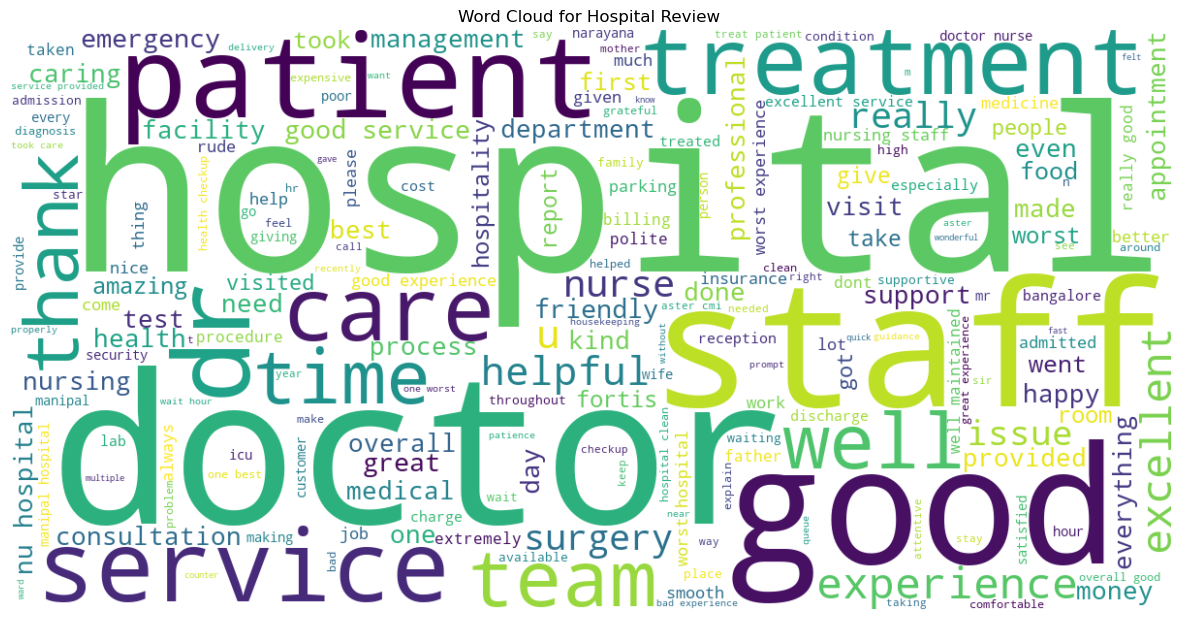

In [46]:
plt.figure(figsize=(15,8))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Hospital Review ")

In [47]:
## After we remove the stop reviews we want to check if we still have a good length for the reviews 

In [48]:
df['Clean_Length'] = df['StoppedTokens'].apply(len)

In [49]:
df['Clean_Length'].describe()

count    951.000000
mean      11.272345
std        5.648518
min        1.000000
25%        8.000000
50%       10.000000
75%       14.000000
max       80.000000
Name: Clean_Length, dtype: float64

In [50]:
## df = df[df['Cleaned_Length'] >= 3] This would be used to remove all the short reviews 
## For topic modelling it is important to include justification 

In [ ]:
## Bigram analysos -  Brings 2 words togethor and sees if they make sense and applies a score to them to see how much sense or meaning it has 
## and Trigram analysis is 3 words 
